# 07 · Sensitivity Analysis (OAT and Latin Hypercube Sampling)

How sensitive is the tuned XGBoost model's weight-class prediction to each input?

- **One-at-a-time (OAT):** perturb one feature at a time by ±10% and measure the change in obesity/overweight risk
- **Grid sensitivity:** sweep the modifiable features (`FAF`, `CH2O`, `CAEC`) individually and together
- **Latin hypercube sampling (LHS):** sample the whole input space and measure per-class probability spread

> **Note:** this is an archival notebook from the original MTFC 2025 run. Outputs are preserved as-is; the dataset (`ObesityDataSet_raw_and_data_sinthetic.csv`) and trained model files are not included in the repo (see the main README for download links).

## Setup

In [1]:
import pickle

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score

# Tuned XGBoost model and test split saved by 04_xgboost_tuned_and_monte_carlo.ipynb
with open("final_model_xgb.pkl", "rb") as f:
    model = pickle.load(f)

X_test = pd.read_csv("xgb_test_x.csv", index_col=0)
y_test = np.loadtxt("xgb_test_y.csv", delimiter=",")

In [2]:
from sklearn.metrics import accuracy_score

# Get model predictions (choosing the class with the highest probability)
y_pred = model.predict(X_test)

# Calculate accuracy
model_accuracy = accuracy_score(y_test, y_pred)

# Print the accuracy
print(f"Model Accuracy: {model_accuracy:.4f}")

Model Accuracy: 0.8582


## One-at-a-time (OAT): change in obesity and overweight risk

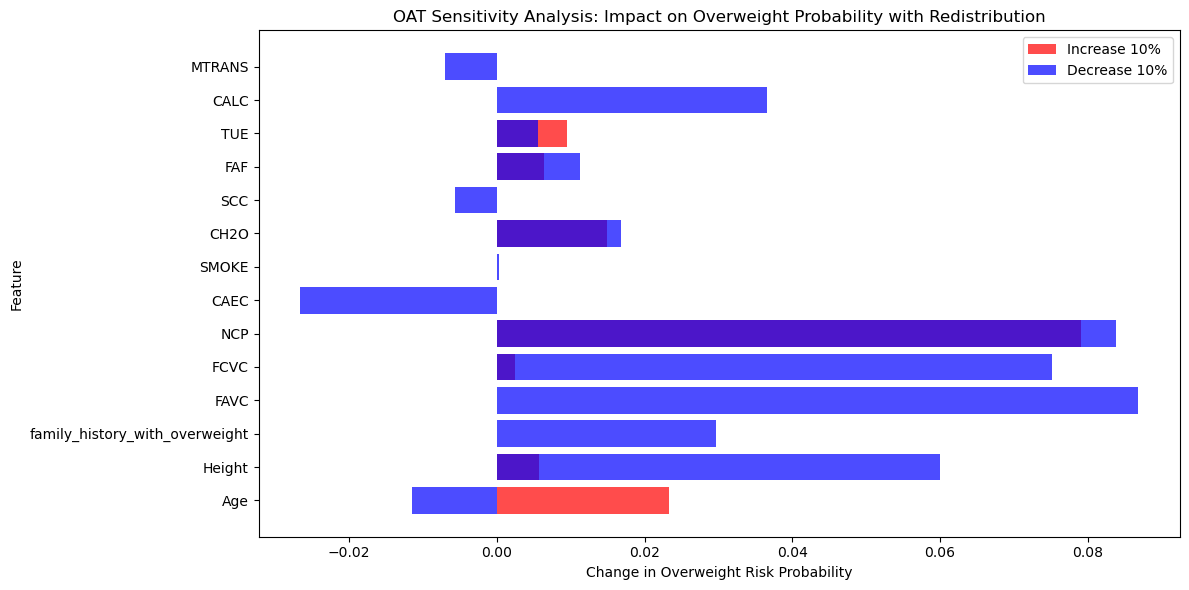

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- OAT Analysis (Impact on Obesity & Overweight Risk) ----
oat_results = []
perturbation_factor = 0.1  # 10% increase/decrease

# Define class indexes
insufficient_weight_idx = 0
normal_weight_idx = 1
obesity_classes = [2, 3, 4]  # Obesity Type I, II, III
overweight_classes = [5, 6]  # Overweight classes (unordered severity)

for feature in X_test.columns:
    X_perturbed_up = X_test.copy()
    X_perturbed_down = X_test.copy()

    # Increase & Decrease feature by 10%
    X_perturbed_up[feature] *= (1 + perturbation_factor)
    X_perturbed_down[feature] *= (1 - perturbation_factor)

    # Get new predictions
    probs_up = model.predict_proba(X_perturbed_up)
    probs_down = model.predict_proba(X_perturbed_down)

    # Compute probability changes for overweight and obesity
    overweight_prob_baseline = np.sum(baseline_probs[:, overweight_classes], axis=1)
    obesity_prob_baseline = np.sum(baseline_probs[:, obesity_classes], axis=1)

    overweight_prob_up = np.sum(probs_up[:, overweight_classes], axis=1)
    overweight_prob_down = np.sum(probs_down[:, overweight_classes], axis=1)

    obesity_prob_up = np.sum(probs_up[:, obesity_classes], axis=1)
    obesity_prob_down = np.sum(probs_down[:, obesity_classes], axis=1)

    # Net probability shift
    overweight_change_up = np.mean(overweight_prob_up - overweight_prob_baseline)
    overweight_change_down = np.mean(overweight_prob_down - overweight_prob_baseline)

    obesity_shift_up = np.mean(obesity_prob_up - obesity_prob_baseline)
    obesity_shift_down = np.mean(obesity_prob_down - obesity_prob_baseline)

    # Consider probability redistribution when overweight probability changes
    overweight_redistributed_up = overweight_change_up - obesity_shift_up
    overweight_redistributed_down = overweight_change_down - obesity_shift_down

    # Store results
    oat_results.append([feature, overweight_change_up, overweight_redistributed_up, overweight_change_down, overweight_redistributed_down])

# Convert to DataFrame for visualization
oat_df = pd.DataFrame(oat_results, columns=["Feature", "Overweight Change (Up)", "Redistributed Overweight (Up)", 
                                            "Overweight Change (Down)", "Redistributed Overweight (Down)"])

# Define the selected columns for plotting
selected_columns = ["Feature", "Overweight Change (Up)", "Overweight Change (Down)"]
oat_df_selected = oat_df[selected_columns]

# Create a bar chart for overweight probability shifts
plt.figure(figsize=(12, 6))

# Plot Overweight Change (Up) and Overweight Change (Down)
plt.barh(oat_df_selected["Feature"], oat_df_selected["Overweight Change (Up)"], color="red", alpha=0.7, label="Increase 10%")
plt.barh(oat_df_selected["Feature"], oat_df_selected["Overweight Change (Down)"], color="blue", alpha=0.7, label="Decrease 10%")

# Formatting
plt.xlabel("Change in Overweight Risk Probability")
plt.ylabel("Feature")
plt.title("OAT Sensitivity Analysis: Impact on Overweight Probability with Redistribution")
plt.legend()
plt.tight_layout()

# Show the plot
plt.show()

In [4]:
# ---- Display OAT Results ----
print("\n===== OAT Sensitivity Analysis Results =====")
print(oat_df.to_string(index=False))


===== OAT Sensitivity Analysis Results =====
                       Feature  Obesity Change (Up)  Obesity Change (Down)  Overweight Change (Up)  Overweight Change (Down)
                           Age             0.003219              -0.085353                0.067339                 -0.011670
                        Height            -0.004226              -0.109709               -0.010028                  0.107186
family_history_with_overweight             0.000000              -0.142212                0.000000                  0.029676
                          FAVC             0.000000              -0.090479                0.000000                  0.086811
                          FCVC             0.019471              -0.076998               -0.013046                  0.097700
                           NCP            -0.116225              -0.067907                0.081194                  0.114619
                          CAEC             0.000000              -0.085275     

## OAT: change in predicted class frequencies

In [5]:
import numpy as np
import pandas as pd
import joblib  # For loading trained models

# ---- Load Trained Model ----
model = joblib.load("final_model_xgb.pkl")  # Replace with your trained model file

# ---- Load Test Dataset ----
X_test = pd.read_csv("xgb_test_x.csv", index_col = 0)  # Replace with actual test data file

# ---- OAT Sensitivity Analysis for Mean Change in Class Frequency ----
num_classes = 7  # Your model predicts 7 classes
perturbation_factor = 0.1  # 10% increase/decrease

# Define class groupings
obesity_classes = [2, 3, 4]  # Obesity Type I, II, III
overweight_classes = [5, 6]  # Overweight classes

# Get baseline class predictions
baseline_preds = model.predict(X_test)

# Compute baseline frequency of each class
baseline_freq = np.zeros(num_classes)
for i in range(num_classes):
    baseline_freq[i] = np.sum(baseline_preds == i) / len(baseline_preds) * 100  # Convert to percentage

# Compute grouped baseline frequencies
baseline_obesity_freq = np.sum(baseline_freq[obesity_classes])
baseline_overweight_freq = np.sum(baseline_freq[overweight_classes])

# Features to perturb
features_to_perturb = ['CAEC', 'FAF', 'CH2O']

# Initialize storage
oat_results = []

for feature in features_to_perturb:  # Only perturb selected features
    X_perturbed_up = X_test.copy()
    X_perturbed_down = X_test.copy()

    # Increase & Decrease feature by 10%
    X_perturbed_up[feature] *= (1 + perturbation_factor)
    X_perturbed_down[feature] *= (1 - perturbation_factor)

    # Get new predictions (class labels, not probabilities)
    preds_up = model.predict(X_perturbed_up)
    preds_down = model.predict(X_perturbed_down)

    # Compute frequency change for each class
    changes_up = []
    changes_down = []

    for i in range(num_classes):
        freq_up = np.sum(preds_up == i) / len(preds_up) * 100  # Percentage of samples in class i
        freq_down = np.sum(preds_down == i) / len(preds_down) * 100

        change_up = freq_up - baseline_freq[i]  # Difference from baseline
        change_down = freq_down - baseline_freq[i]

        changes_up.append(change_up)
        changes_down.append(change_down)

    # Compute changes for grouped obesity and overweight classes
    obesity_change_up = np.sum([changes_up[i] for i in obesity_classes])
    obesity_change_down = np.sum([changes_down[i] for i in obesity_classes])
    overweight_change_up = np.sum([changes_up[i] for i in overweight_classes])
    overweight_change_down = np.sum([changes_down[i] for i in overweight_classes])

    # Store results
    oat_results.append([feature] + changes_up[:2] + [obesity_change_up, overweight_change_up] +
                       changes_down[:2] + [obesity_change_down, overweight_change_down])

# Create DataFrame for results
columns = ["Feature"] + \
          ["Insufficient Weight Mean Change Freq (Up) %", "Normal Weight Mean Change Freq (Up) %"] + \
          ["Obesity Mean Change Freq (Up) %", "Overweight Mean Change Freq (Up) %"] + \
          ["Insufficient Weight Mean Change Freq (Down) %", "Normal Weight Mean Change Freq (Down) %"] + \
          ["Obesity Mean Change Freq (Down) %", "Overweight Mean Change Freq (Down) %"]

oat_df = pd.DataFrame(oat_results, columns=columns)

# Print only the mean
print(oat_df.to_string(index=False))

Feature  Insufficient Weight Mean Change Freq (Up) %  Normal Weight Mean Change Freq (Up) %  Obesity Mean Change Freq (Up) %  Overweight Mean Change Freq (Up) %  Insufficient Weight Mean Change Freq (Down) %  Normal Weight Mean Change Freq (Down) %  Obesity Mean Change Freq (Down) %  Overweight Mean Change Freq (Down) %
   CAEC                                     0.000000                               0.000000                         0.000000                            0.000000                                       5.437352                                 4.728132                          -7.092199                             -3.073286
    FAF                                     0.472813                              -0.472813                         0.945626                           -0.945626                                       1.418440                                -3.546099                           0.945626                              1.182033
   CH2O                           

In [6]:
import pandas as pd

# For each feature (row) in oat_df, get the top 3 changes (by absolute value) among the class change columns
summary_data = []

for idx, row in oat_df.iterrows():
    feature = row['Feature']
    # Exclude the "Feature" column and convert the rest to numeric
    changes = row.drop('Feature').astype(float)
    
    # Get the top 3 indices based on absolute value of change
    top3_indices = changes.abs().nlargest(3).index.tolist()
    
    # Build a summary string for each top change: "Column: value% (Up/Down)"
    feature_summary = []
    for col in top3_indices:
        value = changes[col]
        direction = "Up" if value > 0 else "Down"
        feature_summary.append(f"{col}: {value:.2f}% ({direction})")
    
    summary_data.append([feature] + feature_summary)

# Create a summary DataFrame with appropriate column headers
summary_columns = ["Feature", "Top Change 1", "Top Change 2", "Top Change 3"]
summary_df = pd.DataFrame(summary_data, columns=summary_columns)

# Print the summary table
print(summary_df.to_string(index=False))

Feature                                           Top Change 1                                              Top Change 2                                           Top Change 3
   CAEC       Obesity Mean Change Freq (Down) %: -7.09% (Down) Insufficient Weight Mean Change Freq (Down) %: 5.44% (Up)    Normal Weight Mean Change Freq (Down) %: 4.73% (Up)
    FAF Normal Weight Mean Change Freq (Down) %: -3.55% (Down) Insufficient Weight Mean Change Freq (Down) %: 1.42% (Up)       Overweight Mean Change Freq (Down) %: 1.18% (Up)
   CH2O   Normal Weight Mean Change Freq (Up) %: -4.96% (Down)               Obesity Mean Change Freq (Up) %: 2.60% (Up) Normal Weight Mean Change Freq (Down) %: -2.60% (Down)


## Grid sensitivity of the modifiable features

### Obese individuals

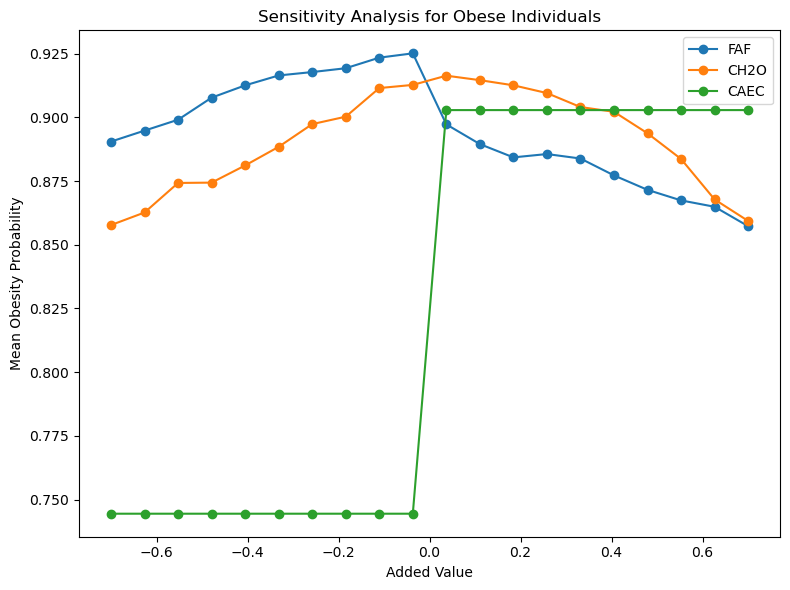

In [7]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# Define a helper function to compute obesity probability.
# This is the sum of probabilities for Obesity_Type_I, II, and III (classes 2, 3, 4).
def obesity_probability(probs):
    return probs[2] + probs[3] + probs[4]

# Define the grid for each modifiable feature.
# These values will be added to the original feature values.
grid = {
    "FAF": np.linspace(0.7, -0.7, 20),
    "CH2O": np.linspace(0.7, -0.7, 20),
    "CAEC": np.linspace(0.7, -0.7, 20)
}

# Get indices for obese individuals based on the model's predictions.
predicted_labels = model.predict(X_test)
obese_class_indices = [2, 3, 4]
obese_indices = [i for i in range(X_test.shape[0]) if predicted_labels[i] in obese_class_indices]

# Dictionary to store sensitivity results for each feature.
sensitivity_results = {feature: {"values": [], "mean_obesity_prob": []} for feature in ["FAF", "CH2O", "CAEC"]}

# For each feature, vary that feature's value over the grid while keeping other features fixed.
for feature in sensitivity_results:
    # Get the original range for this feature from the entire X_test.
    orig_min = X_test[feature].min()
    orig_max = X_test[feature].max()
    
    # List to accumulate the obesity probability curves for each individual.
    all_individual_probs = []
    for i in obese_indices:
        X_i = X_test.iloc[i].copy()
        individual_probs = []
        for val in grid[feature]:
            X_modified = X_i.copy()
            new_val = X_modified[feature] + val
            # If new_val is outside the original observed range, skip this candidate (set as NaN).
            if new_val < orig_min or new_val > orig_max:
                individual_probs.append(np.nan)
            else:
                X_modified[feature] = new_val
                prob = model.predict_proba(X_modified.values.reshape(1, -1))[0]
                individual_probs.append(obesity_probability(prob))
        all_individual_probs.append(individual_probs)
    # Convert to numpy array and compute the mean obesity probability at each grid value across individuals,
    # ignoring NaNs.
    all_individual_probs = np.array(all_individual_probs)
    mean_probs = np.nanmean(all_individual_probs, axis=0)
    sensitivity_results[feature]["values"] = grid[feature]
    sensitivity_results[feature]["mean_obesity_prob"] = mean_probs

# Plot the sensitivity analysis results.
plt.figure(figsize=(8, 6))
for feature in sensitivity_results:
    plt.plot(sensitivity_results[feature]["values"], sensitivity_results[feature]["mean_obesity_prob"],
             marker='o', label=feature)
plt.xlabel("Added Value")
plt.ylabel("Mean Obesity Probability")
plt.title("Sensitivity Analysis for Obese Individuals")
plt.legend()
plt.tight_layout()
#plt.savefig("sensitivity_analysis_obese.png", dpi=300, bbox_inches='tight')
plt.show()

### Single-class probability sweep

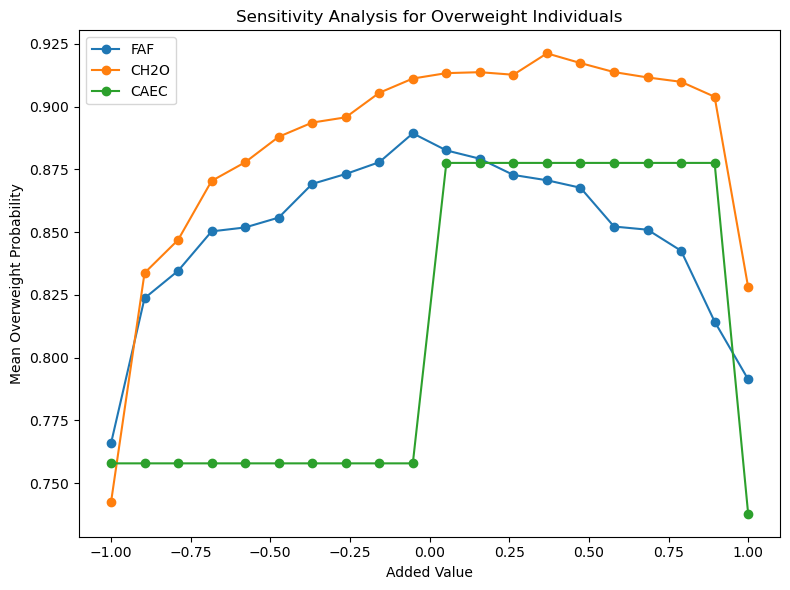

In [8]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# Define a helper function to compute overweight probability.
# Here, overweight probability is defined as the sum of probabilities for Overweight_Level_I and Overweight_Level_II (classes 5 and 6).
def overweight_probability(probs):
    return probs[0]

# Define the grid for each modifiable feature.
# These values will be added to the original feature values.
grid = {
    "FAF": np.linspace(1, -1, 20),
    "CH2O": np.linspace(1, -1, 20),
    "CAEC": np.linspace(1, -1, 20)
}

# Get indices for overweight individuals based on the model's predictions.
predicted_labels = model.predict(X_test)
# Overweight classes are assumed to be classes 5 and 6.
overweight_class_indices = [0]
overweight_indices = [i for i in range(X_test.shape[0]) if predicted_labels[i] in overweight_class_indices]

# Dictionary to store sensitivity results for each feature.
sensitivity_results = {feature: {"values": [], "mean_overweight_prob": []} for feature in ["FAF", "CH2O", "CAEC"]}

# For each feature, vary that feature's value over the grid while keeping other features fixed.
for feature in sensitivity_results:
    # Get the original range for this feature from X_test.
    orig_min = X_test[feature].min()
    orig_max = X_test[feature].max()
    
    # List to accumulate the overweight probability curves for each individual.
    all_individual_probs = []
    for i in overweight_indices:
        X_i = X_test.iloc[i].copy()
        individual_probs = []
        for val in grid[feature]:
            X_modified = X_i.copy()
            # Add the grid value to the original feature value.
            new_val = X_modified[feature] + val
            # Check if new_val is within the original observed range.
            if new_val < orig_min or new_val > orig_max:
                individual_probs.append(np.nan)
            else:
                X_modified[feature] = new_val
                # Predict probabilities using the model.
                prob = model.predict_proba(X_modified.values.reshape(1, -1))[0]
                individual_probs.append(overweight_probability(prob))
        all_individual_probs.append(individual_probs)
    # Compute the mean overweight probability at each grid value across individuals, ignoring NaNs.
    all_individual_probs = np.array(all_individual_probs)
    mean_probs = np.nanmean(all_individual_probs, axis=0)
    sensitivity_results[feature]["values"] = grid[feature]
    sensitivity_results[feature]["mean_overweight_prob"] = mean_probs

# Plot the sensitivity analysis results for overweight individuals.
plt.figure(figsize=(8, 6))
for feature in sensitivity_results:
    plt.plot(sensitivity_results[feature]["values"], sensitivity_results[feature]["mean_overweight_prob"],
             marker='o', label=feature)
plt.xlabel("Added Value")
plt.ylabel("Mean Overweight Probability")
plt.title("Sensitivity Analysis for Overweight Individuals")
plt.legend()
plt.tight_layout()
plt.savefig("sensitivity_analysis_overweight.png", dpi=300, bbox_inches='tight')
plt.show()

### All weight categories, individual and composite changes

In [9]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

# Define a helper function to compute group probability.
def group_probability(probs, group):
    return np.sum([probs[i] for i in group])

# Define the grid for each modifiable feature.
# These values will be added to the original feature values.
grid = {
    "FAF": np.linspace(0.8, -0.8, 20),
    "CH2O": np.linspace(0.8, -0.8, 20),
    "CAEC": np.linspace(0.8, -0.8, 20)
}

# Define a composite grid for the composite sensitivity analysis.
composite_grid = np.linspace(0.8, -0.8, 20)

# Define target groups mapping to class indices.
# Note: Overweight is placed before Obese.
groups = {
    "Insufficient_Weight": [0],
    "Normal_Weight": [1],
    "Overweight": [5, 6],
    "Obese": [2, 3, 4]
}

# Get model predictions for the entire test set.
predicted_labels = model.predict(X_test)

# Prepare a dictionary to hold sensitivity results for each group and each feature.
# Each group will have an entry for each individual feature and one for the composite analysis.
sensitivity_results = {
    group_name: { 
        feature: {"values": grid[feature], "mean_prob": []}
        for feature in grid.keys()
    }
    for group_name in groups.keys()
}

# We'll add a "Composite" entry later for each group.
for group_name in groups.keys():
    sensitivity_results[group_name]["Composite"] = {"values": composite_grid, "mean_prob": []}

# For each target group...
for group_name, class_indices in groups.items():
    # Get indices of samples in this group.
    group_indices = [i for i in range(X_test.shape[0]) if predicted_labels[i] in class_indices]
    
    # Sensitivity analysis for each individual feature.
    for feature in grid.keys():
        all_individual_probs = []
        # Get the original range for this feature from X_test.
        orig_min = X_test[feature].min()
        orig_max = X_test[feature].max()
        for i in group_indices:
            X_i = X_test.iloc[i].copy()
            individual_probs = []
            for val in grid[feature]:
                X_modified = X_i.copy()
                # Add the grid value to the original feature value.
                new_val = X_modified[feature] + val
                # Clip new_val to the original observed range.
                new_val = np.clip(new_val, orig_min, orig_max)
                X_modified[feature] = new_val
                # Predict probabilities using the model.
                prob = model.predict_proba(X_modified.values.reshape(1, -1))[0]
                individual_probs.append(group_probability(prob, class_indices))
            all_individual_probs.append(individual_probs)
        # Compute the mean probability at each grid value across individuals, ignoring NaNs.
        all_individual_probs = np.array(all_individual_probs)
        mean_probs = np.nanmean(all_individual_probs, axis=0)
        sensitivity_results[group_name][feature]["mean_prob"] = mean_probs

    # Composite sensitivity analysis: add the same scalar to all modifiable features,
    # but reverse the change for CAEC.
    all_composite_probs = []
    for i in group_indices:
        X_i = X_test.iloc[i].copy()
        individual_probs = []
        for s in composite_grid:
            X_modified = X_i.copy()
            for feature in grid.keys():
                orig_min = X_test[feature].min()
                orig_max = X_test[feature].max()
                # For CAEC, subtract s; for others, add s.
                if feature == "CAEC":
                    new_val = X_modified[feature] - s
                else:
                    new_val = X_modified[feature] + s
                new_val = np.clip(new_val, orig_min, orig_max)
                X_modified[feature] = new_val
            # Predict probabilities using the model.
            prob = model.predict_proba(X_modified.values.reshape(1, -1))[0]
            individual_probs.append(group_probability(prob, class_indices))
        all_composite_probs.append(individual_probs)
    all_composite_probs = np.array(all_composite_probs)
    composite_mean_probs = np.nanmean(all_composite_probs, axis=0)
    sensitivity_results[group_name]["Composite"]["mean_prob"] = composite_mean_probs

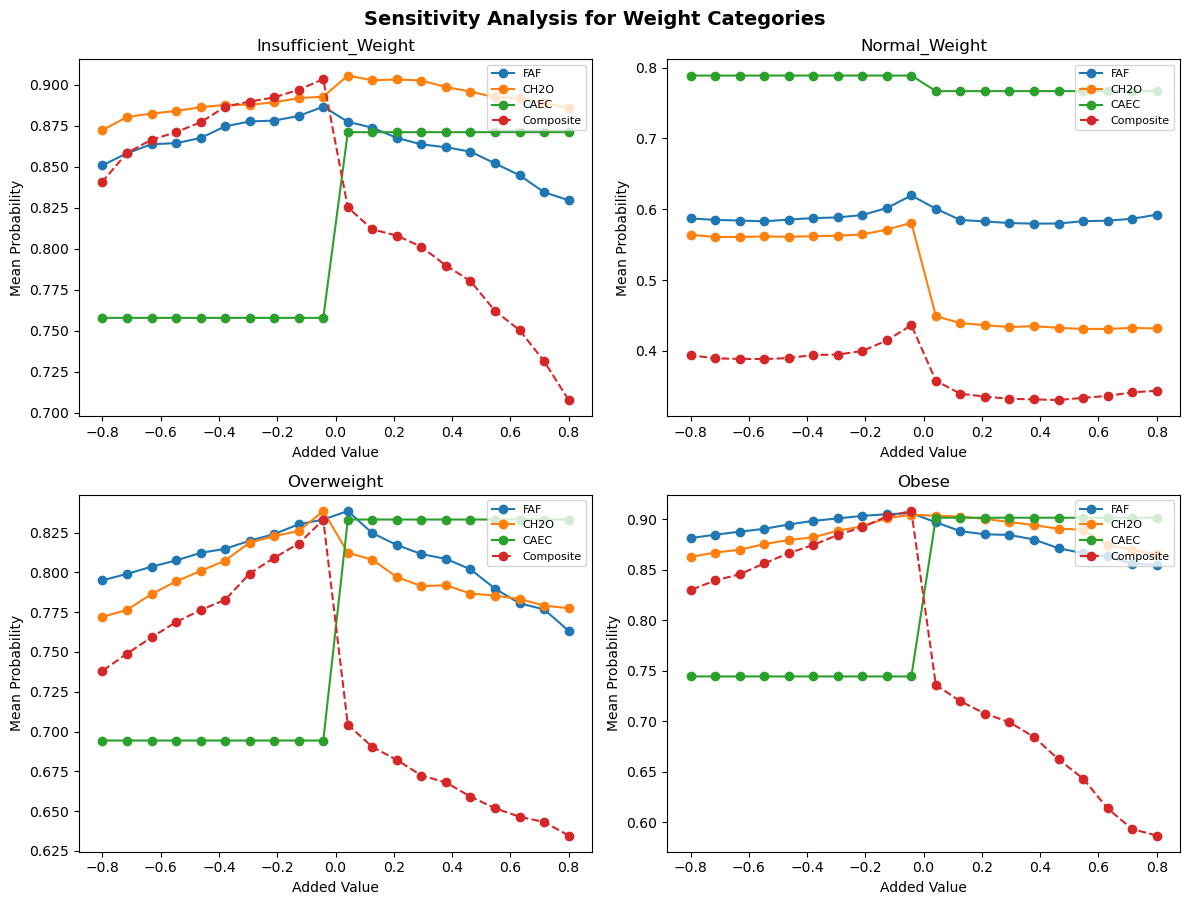

In [10]:
# --- Plotting ---

# Create a 2x2 grid of subplots without shared axes.
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (group_name, feature_data) in enumerate(sensitivity_results.items()):
    ax = axes[idx]
    # Plot each individual feature sensitivity.
    for feature in grid.keys():
        ax.plot(feature_data[feature]["values"], feature_data[feature]["mean_prob"],
                marker='o', label=feature)
    # Plot composite sensitivity.
    ax.plot(feature_data["Composite"]["values"], feature_data["Composite"]["mean_prob"],
            marker='o', linestyle='--', label="Composite")
    ax.set_title(group_name, fontsize=12)
    ax.set_xlabel("Added Value", fontsize=10)
    ax.set_ylabel("Mean Probability", fontsize=10)
    # Force legend to always appear in the upper right corner.
    ax.legend(loc='upper right', fontsize=8)
    
plt.suptitle("Sensitivity Analysis for Weight Categories", fontsize=14, y=0.93, fontweight="bold")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("sensitivity_analysis_weight_categories.png", dpi=300, bbox_inches='tight')
plt.show()

## Latin hypercube sampling (LHS)

In [11]:
from scipy.stats import qmc
# ---- LHS Analysis ----
lhs = qmc.LatinHypercube(d=X_test.shape[1])  # Number of dimensions = features
n_samples = 100  # Number of LHS samples
lhs_samples = lhs.random(n=n_samples)

# Scale LHS samples to match the feature range in X_test (min-max per column)
X_lhs = pd.DataFrame(lhs_samples, columns=X_test.columns)

# Rescale LHS samples to match the original X_test feature range
for feature in X_test.columns:
    X_lhs[feature] = X_lhs[feature] * (X_test[feature].max() - X_test[feature].min()) + X_test[feature].min()

# Get LHS predictions
lhs_probs = model.predict_proba(X_lhs)

# Compute standard deviation of probabilities to measure sensitivity
lhs_sensitivity = np.std(lhs_probs, axis=0)

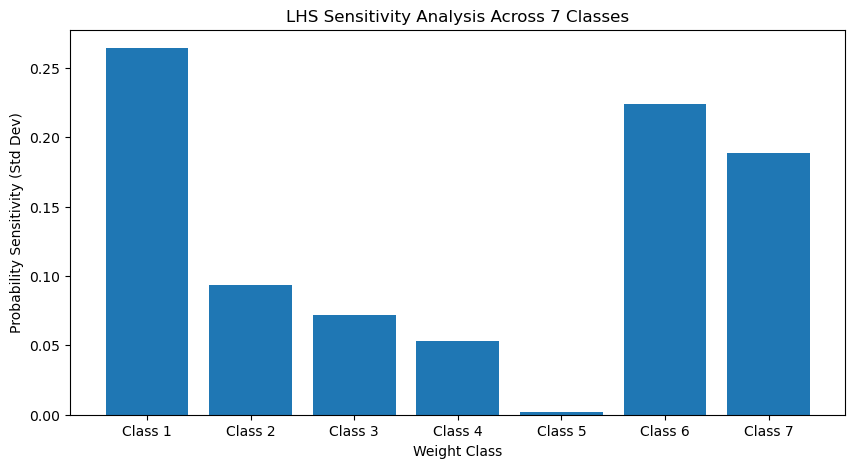

In [12]:
import matplotlib.pyplot as plt
# ---- Plot LHS Sensitivity ----
plt.figure(figsize=(10, 5))
plt.bar(range(7), lhs_sensitivity, tick_label=[f"Class {i+1}" for i in range(7)])
plt.xlabel("Weight Class")
plt.ylabel("Probability Sensitivity (Std Dev)")
plt.title("LHS Sensitivity Analysis Across 7 Classes")
plt.show()